In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapoorprakhar/college-placement-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|███████████████████████████████████████████████████████████████████████████████████| 324/324 [00:00<00:00, 353kB/s]

Extracting files...
Path to dataset files: /Users/groy/.cache/kagglehub/datasets/kapoorprakhar/college-placement-dataset/versions/1


In [18]:
#Loading the dataset so that we can study
df = pd.read_csv('Study Hour(Linear Regression).csv')

In [19]:
#Getting an idea of the dataset we are working with.
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


Text(0, 0.5, 'Scores Recieved: ')

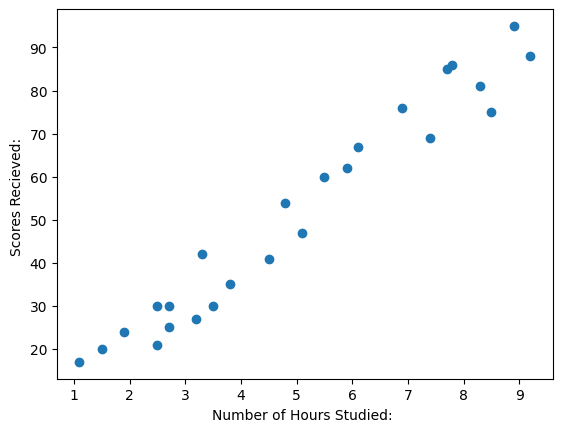

In [8]:
#First Important Step- Plot and visualize the dataset given.
#Identity the algorithm to be used based on the graph.

plt.scatter(df['Hours'], df['Scores'])
plt.xlabel('Number of Hours Studied: ')
plt.ylabel('Scores Recieved: ')

In [21]:
#For SIMPLE LINEAR REGRESSION we seperate the input column and output column into two different rows.

x = df.iloc[:,0:1]
y = df.iloc[:,1:2]

In [44]:
x

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [22]:
y

,Scores
0,21
1,47
2,27
3,75
4,30
5,20
6,88
7,60
8,81
9,25


In [31]:
#Importing the train_test_split function from sklearn.model_selection for the same

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
# Using the function train_test_split to split (X,Y) into train,test. Using parameters test_size to split 20% of the data into test set and random_state to randomize the train set.
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=2)

In [34]:
# Now, importing the LinearRegression function from the scklearn.linear_model to run said ML Algorithm

In [35]:
from sklearn.linear_model import LinearRegression

In [39]:
#Creating an object of the Linear Regression model
lr = LinearRegression()

In [40]:
type(lr)

sklearn.linear_model._base.LinearRegression

In [41]:
#The lr is an object of the above class

In [84]:
#lr.fit() trains the model
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[12.44258714]])

In [86]:
x_test

,Hours
14,1.1
0,2.5
17,1.9
6,9.2
23,6.9


In [87]:
y_test

,Scores
14,17
0,21
17,24
6,88
23,76


In [88]:
#Predicting the value of row 3 in x_test dataset

In [89]:
#l x_test.iloc[0] returns a series datatype. .values() turns the series datatype into a numpy array datatype.
# .reshape(1,1) turns the 1D array into a 2D array, as lr.predict takes a 2d array as input with the n_samples, n_features.

lr.predict(x_test.iloc[2].values.reshape(1,1))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[20.39507925]])

In [90]:
x_test.iloc[2].values

array([1.9])

Text(0, 0.5, 'Hours')

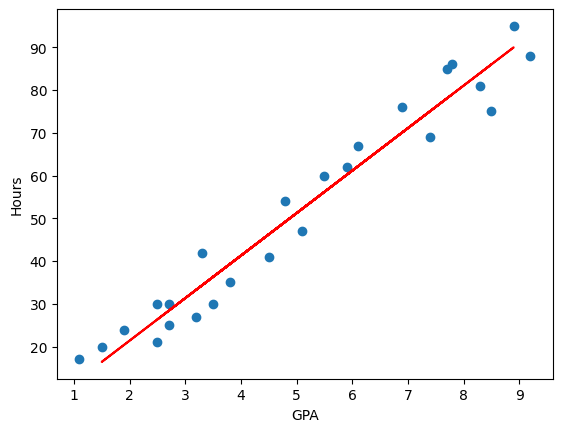

In [91]:
#PLotting the linear function line along with the scatter plot drawn before.

plt.scatter(x, y)
plt.plot(x_train, lr.predict(x_train), color='red')
plt.xlabel("GPA")
plt.ylabel("Hours")

In [92]:
# lr.coef_ gives you the slope of the function line and lr.intercept_ gives you the intercept of the line.

In [93]:
slope = lr.coef_

In [94]:
slope

array([[9.94061514]])

In [95]:
b=lr.intercept_

In [96]:
slope*10+b

array([[100.91406191]])

Offset: The intercept (in this case, the variable 'b') is called as the offset. It's main job is to give a value when the input becomes zero. In the absence of an offset, the value of the function becomes zero as the input is 0, which may or may not be zero. To stablize this we introduce a constant like the offset.

This is my understanding of an offset up until now, may or may not completely correct or accurate.

Building a Linear Regression mathematical model from scratch without using scklearn.

There are generally two ways to do this:
1. Close-form Expressions: Which are predefined mathematical formulas.
    - The LinearRegression model in scklearn is built using this.
    - Uses a formula called OLS- Ordinary Least Squared method.

2. Open-form Expressions: Which use approximation techniques to predict an answer.
    - The Stoichotic Gradient Descent Regression model in scklearn is build using this.
    - SGDRegressor uses the Gradient Descent technique 

In [97]:
#First using the OLS(Ordinary Least Square) method